# Informed AI Search Algorithms Implementation  
## PUBG-Inspired Safe Zone Pathfinding Using Greedy Best-First Search and A*

![PUBG Safe Zone](pubg_safe_zone.jpg)

*Figure 1: PUBG-inspired safe zone navigation. The player must reach the safe zone while avoiding dangerous or high-cost areas.*

## 1. Introduction

This project applies informed search algorithms to a PUBG-inspired safe zone navigation problem.

The environment is modeled as a weighted 2D grid map. Each cell represents a terrain type with a different movement cost. The player must move from the starting position to the safe zone while avoiding obstacles and minimizing the total movement cost.

The project implements and compares:

- Greedy Best-First Search
- A* Search

Two admissible heuristic functions are designed and tested:

- Manhattan Distance
- Euclidean Distance

## 2. Problem Scenario

In PUBG, a player must often reach the safe zone before the danger zone closes in. The shortest-looking path is not always the safest or cheapest path because some areas may be difficult, slow, or dangerous to cross.

In this project, the player is represented as an AI agent moving inside a simplified PUBG-style grid map. The map contains different terrain types such as roads, open fields, rocky areas, red zones, and obstacles.

The goal is to find a valid path from the player's starting position to the safe zone with the minimum possible total movement cost.

## 3. Problem Formulation

### Agent

The agent is the PUBG player who needs to reach the safe zone.

### Environment

The environment is a static, fully observable, weighted 2D grid map inspired by a PUBG battlefield.

### Initial State

The initial state is the player's starting position on the grid.

### Goal State

The goal state is the safe zone cell.

### State Representation

Each state is represented as a pair of grid coordinates:

\[
state = (row, column)
\]

### Valid Actions

The player can move in four directions:

- Up
- Down
- Left
- Right

Diagonal movement is not allowed.

### Path Cost

The path cost is the sum of the movement costs of all cells entered by the player.

## 4. PEAS Description

| Component | Description |
|---|---|
| Performance Measure | Reach the safe zone, minimize total movement cost, avoid obstacles, and reduce explored nodes when possible |
| Environment | PUBG-inspired weighted 2D grid map with roads, fields, rocky areas, red zones, and obstacles |
| Actuators | Move Up, Move Down, Move Left, Move Right |
| Sensors | Current position, neighboring cells, terrain type, movement cost, and goal position |

## 5. State Space and Terrain Representation

The PUBG-style map is represented as a 2D grid.

Each cell contains a symbol representing a terrain type:

| Symbol | Terrain Type | Movement Cost |
|---|---|---:|
| S | Start Position | 0 |
| G | Safe Zone / Goal | 1 |
| R | Road | 1 |
| F | Open Field | 2 |
| M | Mountain / Rocky Area | 5 |
| Z | Red Zone / Dangerous Area | 8 |
| X | Obstacle / Blocked Cell | Not allowed |

The objective is not only to minimize the number of steps, but to minimize the total movement cost.

## Imports

In [1]:
import heapq
import time
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Grid

In [2]:
grid = [
    ['S', 'R', 'F', 'M', 'F', 'M', 'R', 'M', 'F', 'F', 'R', 'F'],
    ['M', 'R', 'F', 'M', 'R', 'R', 'R', 'R', 'M', 'R', 'R', 'R'],
    ['F', 'X', 'F', 'F', 'R', 'R', 'F', 'R', 'M', 'R', 'F', 'X'],
    ['R', 'M', 'R', 'R', 'X', 'F', 'R', 'M', 'M', 'R', 'Z', 'F'],
    ['Z', 'R', 'R', 'F', 'X', 'M', 'F', 'R', 'X', 'F', 'R', 'F'],
    ['R', 'F', 'R', 'F', 'F', 'F', 'F', 'M', 'F', 'M', 'Z', 'Z'],
    ['F', 'R', 'F', 'X', 'R', 'R', 'R', 'R', 'R', 'R', 'F', 'M'],
    ['R', 'M', 'R', 'R', 'R', 'F', 'R', 'F', 'F', 'R', 'R', 'R'],
    ['R', 'X', 'F', 'F', 'R', 'R', 'M', 'R', 'X', 'Z', 'R', 'M'],
    ['R', 'X', 'X', 'R', 'X', 'F', 'R', 'F', 'R', 'X', 'R', 'G']
]

terrain_cost = {
    'S': 0,
    'G': 1,
    'R': 1,
    'F': 2,
    'M': 5,
    'Z': 8,
    'X': float('inf')
}

## 6. Heuristic Design

This project uses two heuristic functions.

### Heuristic 1: Manhattan Distance

\[
h_1(n) = |x_n - x_g| + |y_n - y_g|
\]

Manhattan Distance is suitable for this problem because the player can only move in four directions: up, down, left, and right.

### Heuristic 2: Euclidean Distance

\[
h_2(n) = \sqrt{(x_n - x_g)^2 + (y_n - y_g)^2}
\]

Euclidean Distance estimates the straight-line distance between the current state and the goal state.

## 7. Admissibility Proof

A heuristic is admissible if it never overestimates the true optimal cost from the current node to the goal.

\[
h(n) \leq h^*(n)
\]

Where \(h(n)\) is the estimated cost and \(h^*(n)\) is the true optimal cost.

### Manhattan Distance Admissibility

The player can only move horizontally or vertically. Therefore, the minimum number of moves required to reach the goal is at least the Manhattan distance.

Since the minimum movement cost of any valid cell is 1, and obstacles or expensive terrain can only increase the actual path cost, Manhattan Distance never overestimates the true cost.

Therefore, \(h_1(n)\) is admissible.

### Euclidean Distance Admissibility

Euclidean Distance represents the straight-line distance from the current node to the goal. Any real path in a grid without diagonal movement must be at least as long as the straight-line distance.

Since the minimum valid movement cost is 1, Euclidean Distance also never overestimates the true path cost.

Therefore, \(h_2(n)\) is admissible.

## 8. Helper Functions

The following helper functions are used to:

- Locate the start and goal positions
- Validate possible moves
- Generate neighboring cells
- Calculate path cost
- Display the final path on the grid

In [3]:
def find_position(grid, symbol):
    for row in range(len(grid)):
        for col in range(len(grid[0])):
            if grid[row][col] == symbol:
                return (row, col)
    return None


def is_valid_position(grid, position):
    row, col = position
    
    if row < 0 or row >= len(grid):
        return False
    
    if col < 0 or col >= len(grid[0]):
        return False
    
    if grid[row][col] == 'X':
        return False
    
    return True


def get_neighbors(grid, position):
    row, col = position
    
    directions = [
        (row - 1, col),
        (row + 1, col),
        (row, col - 1),
        (row, col + 1)
    ]
    
    neighbors = []
    
    for new_position in directions:
        if is_valid_position(grid, new_position):
            neighbors.append(new_position)
    
    return neighbors


def get_cell_cost(grid, position):
    row, col = position
    cell_type = grid[row][col]
    return terrain_cost[cell_type]


def calculate_path_cost(grid, path):
    total_cost = 0
    
    for position in path[1:]:
        total_cost += get_cell_cost(grid, position)
    
    return total_cost


def display_path(grid, path):
    displayed_grid = [row.copy() for row in grid]
    
    for row, col in path:
        if displayed_grid[row][col] not in ['S', 'G']:
            displayed_grid[row][col] = '*'
    
    for row in displayed_grid:
        print(" ".join(row))

## Heuristic Functions

In [4]:
def manhattan_distance(current, goal):
    x1, y1 = current
    x2, y2 = goal
    return abs(x1 - x2) + abs(y1 - y2)


def euclidean_distance(current, goal):
    x1, y1 = current
    x2, y2 = goal
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

## 9. Greedy Best-First Search

Greedy Best-First Search expands the node that appears closest to the goal according to the heuristic value.

\[
f(n) = h(n)
\]

This algorithm does not consider the cost already paid from the start node. Therefore, it may choose a path that looks close to the goal but has a high total movement cost.

In [5]:
def greedy_best_first_search(grid, start, goal, heuristic):
    priority_queue = []
    heapq.heappush(priority_queue, (heuristic(start, goal), start, [start]))
    
    visited = set()
    nodes_explored = 0
    
    while priority_queue:
        h_value, current, path = heapq.heappop(priority_queue)
        
        if current in visited:
            continue
        
        visited.add(current)
        nodes_explored += 1
        
        if current == goal:
            path_cost = calculate_path_cost(grid, path)
            return path, path_cost, nodes_explored
        
        for neighbor in get_neighbors(grid, current):
            if neighbor not in visited:
                new_path = path + [neighbor]
                heapq.heappush(
                    priority_queue,
                    (heuristic(neighbor, goal), neighbor, new_path)
                )
    
    return None, None, nodes_explored

In [6]:
start = find_position(grid, 'S')
goal = find_position(grid, 'G')

print("Start Position:", start)
print("Goal Position:", goal)

start_time = time.time()

greedy_path, greedy_cost, greedy_nodes = greedy_best_first_search(
    grid,
    start,
    goal,
    manhattan_distance
)

greedy_time = time.time() - start_time

print("\nGreedy Best-First Search Result")
print("-" * 40)
print("Heuristic Used: Manhattan Distance")
print("Path:", greedy_path)
print("Path Cost:", greedy_cost)
print("Nodes Explored:", greedy_nodes)
print("Execution Time:", greedy_time)

print("\nPath on Grid:")
display_path(grid, greedy_path)

Start Position: (0, 0)
Goal Position: (9, 11)

Greedy Best-First Search Result
----------------------------------------
Heuristic Used: Manhattan Distance
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (1, 11), (1, 10), (2, 10), (3, 10), (3, 11), (4, 11), (5, 11), (6, 11), (7, 11), (8, 11), (9, 11)]
Path Cost: 64
Nodes Explored: 23
Execution Time: 0.00018739700317382812

Path on Grid:
S * * * * * * * * * * *
M R F M R R R R M R * *
F X F F R R F R M R * X
R M R R X F R M M R * *
Z R R F X M F R X F R *
R F R F F F F M F M Z *
F R F X R R R R R R F *
R M R R R F R F F R R *
R X F F R R M R X Z R *
R X X R X F R F R X R G


## 10. A* Search

A* Search evaluates each node using the following evaluation function:

\[
f(n) = g(n) + h(n)
\]

Where:

- \(g(n)\) is the actual cost from the start node to the current node.
- \(h(n)\) is the estimated cost from the current node to the goal.
- \(f(n)\) is the total estimated cost used to choose the next node.

Unlike Greedy Best-First Search, A* considers both the accumulated path cost and the estimated remaining cost. Therefore, when the heuristic is admissible, A* can find the optimal path.

In [ ]:
def a_star_search(grid, start, goal, heuristic):
    priority_queue = []
    heapq.heappush(priority_queue, (heuristic(start, goal), 0, start, [start]))
    
    best_cost = {start: 0} // بيحفظ اقل تكلفة وصلنا بيها لكل نود
    closed_set = set()
    nodes_explored = 0
    
    while priority_queue:
        f_value, g_value, current, path = heapq.heappop(priority_queue)
        
        if current in closed_set:
            continue
        
        closed_set.add(current)
        nodes_explored += 1
        
        if current == goal:
            return path, g_value, nodes_explored
        
        for neighbor in get_neighbors(grid, current):
            new_g_value = g_value + get_cell_cost(grid, neighbor)
            
            if neighbor not in best_cost or new_g_value < best_cost[neighbor]:
                best_cost[neighbor] = new_g_value
                
                h_value = heuristic(neighbor, goal)
                new_f_value = new_g_value + h_value
                new_path = path + [neighbor]
                
                heapq.heappush(
                    priority_queue,
                    (new_f_value, new_g_value, neighbor, new_path)
                )
    
    return None, None, nodes_explored

## A* with h1 Output

In [8]:
start_time = time.time()

astar_h1_path, astar_h1_cost, astar_h1_nodes = a_star_search(
    grid,
    start,
    goal,
    manhattan_distance
)

astar_h1_time = time.time() - start_time

print("A* Search Result using h1")
print("-" * 40)
print("Heuristic Used: h1 = Manhattan Distance")
print("Path:", astar_h1_path)
print("Path Cost:", astar_h1_cost)
print("Nodes Explored:", astar_h1_nodes)
print("Execution Time:", astar_h1_time)

print("\nPath on Grid:")
display_path(grid, astar_h1_path)

A* Search Result using h1
----------------------------------------
Heuristic Used: h1 = Manhattan Distance
Path: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (5, 3), (5, 4), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (7, 9), (7, 10), (8, 10), (9, 10), (9, 11)]
Path Cost: 24
Nodes Explored: 47
Execution Time: 0.0001957416534423828

Path on Grid:
S * F M F M R M F F R F
M * * M R R R R M R R R
F X * F R R F R M R F X
R M * R X F R M M R Z F
Z R * F X M F R X F R F
R F * * * F F M F M Z Z
F R F X * * * * * * F M
R M R R R F R F F * * R
R X F F R R M R X Z * M
R X X R X F R F R X * G


## A* with h2 Output

In [9]:
start_time = time.time()

astar_h2_path, astar_h2_cost, astar_h2_nodes = a_star_search(
    grid,
    start,
    goal,
    euclidean_distance
)

astar_h2_time = time.time() - start_time

print("A* Search Result using h2")
print("-" * 40)
print("Heuristic Used: h2 = Euclidean Distance")
print("Path:", astar_h2_path)
print("Path Cost:", astar_h2_cost)
print("Nodes Explored:", astar_h2_nodes)
print("Execution Time:", astar_h2_time)

print("\nPath on Grid:")
display_path(grid, astar_h2_path)

A* Search Result using h2
----------------------------------------
Heuristic Used: h2 = Euclidean Distance
Path: [(0, 0), (0, 1), (1, 1), (1, 2), (2, 2), (3, 2), (4, 2), (5, 2), (5, 3), (5, 4), (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (6, 9), (7, 9), (7, 10), (8, 10), (9, 10), (9, 11)]
Path Cost: 24
Nodes Explored: 67
Execution Time: 0.00025653839111328125

Path on Grid:
S * F M F M R M F F R F
M * * M R R R R M R R R
F X * F R R F R M R F X
R M * R X F R M M R Z F
Z R * F X M F R X F R F
R F * * * F F M F M Z Z
F R F X * * * * * * F M
R M R R R F R F F * * R
R X F F R R M R X Z * M
R X X R X F R F R X * G


## 11. Results Table

The following table summarizes the performance of the implemented informed search algorithms.

The algorithms are compared based on:

- Path cost
- Number of explored nodes
- Execution time
- Heuristic function used

This comparison is required to evaluate the behavior of Greedy Best-First Search and A* Search in the same weighted environment.

In [10]:
results = [
    {
        "Algorithm": "Greedy Best-First Search",
        "Heuristic": "Manhattan Distance",
        "Path Cost": greedy_cost,
        "Nodes Explored": greedy_nodes,
        "Execution Time": greedy_time,
        "Path": greedy_path
    },
    {
        "Algorithm": "A* Search",
        "Heuristic": "h1: Manhattan Distance",
        "Path Cost": astar_h1_cost,
        "Nodes Explored": astar_h1_nodes,
        "Execution Time": astar_h1_time,
        "Path": astar_h1_path
    },
    {
        "Algorithm": "A* Search",
        "Heuristic": "h2: Euclidean Distance",
        "Path Cost": astar_h2_cost,
        "Nodes Explored": astar_h2_nodes,
        "Execution Time": astar_h2_time,
        "Path": astar_h2_path
    }
]

df_results = pd.DataFrame(results)
df_results[["Algorithm", "Heuristic", "Path Cost", "Nodes Explored", "Execution Time"]]

,Algorithm,Heuristic,Path Cost,Nodes Explored,Execution Time
0,Greedy Best-First Search,Manhattan Distance,64,23,0.000187
1,A* Search,h1: Manhattan Distance,24,47,0.000196
2,A* Search,h2: Euclidean Distance,24,67,0.000257


## Main Experiment Results Visualization

The following charts visualize the main experiment results.  
They compare Greedy Best-First Search, A* using Manhattan Distance, and A* using Euclidean Distance based on:

- Path cost
- Number of explored nodes
- Execution time

## Path Cost Comparison

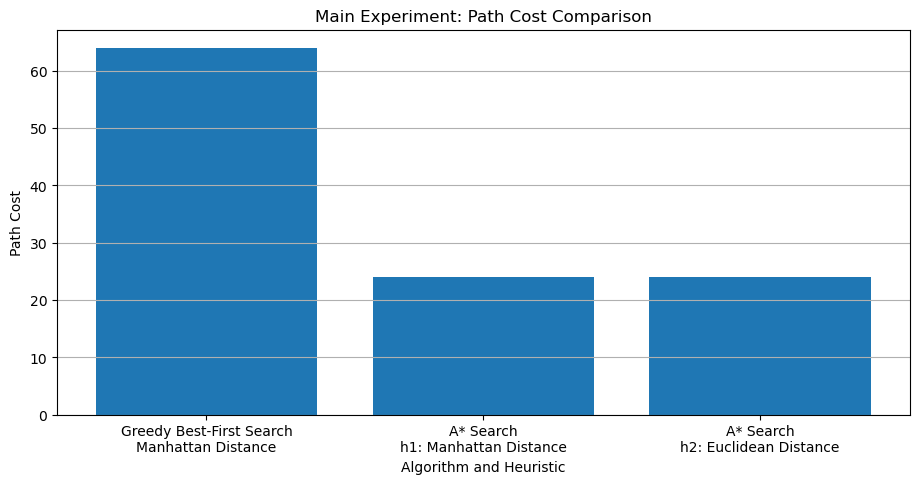

In [11]:
labels = df_results["Algorithm"] + "\n" + df_results["Heuristic"]

plt.figure(figsize=(11, 5))
plt.bar(labels, df_results["Path Cost"])
plt.title("Main Experiment: Path Cost Comparison")
plt.xlabel("Algorithm and Heuristic")
plt.ylabel("Path Cost")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Nodes Explored Comparison

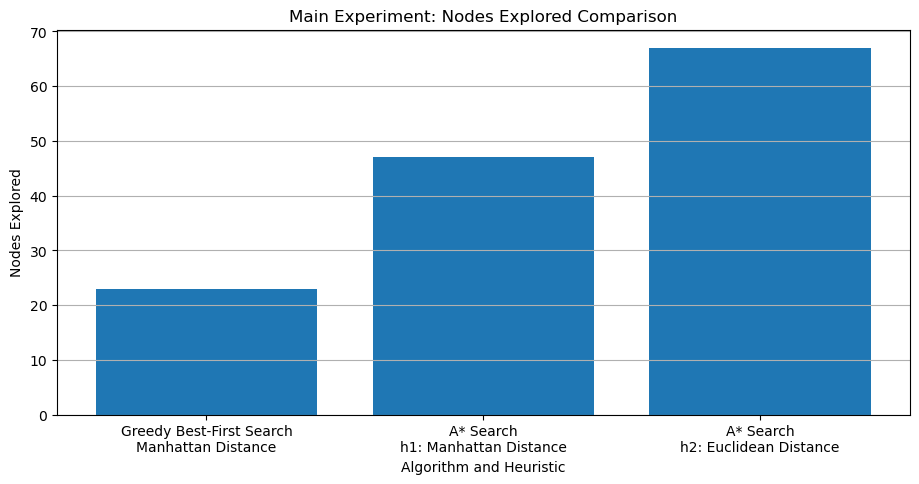

In [12]:
labels = df_results["Algorithm"] + "\n" + df_results["Heuristic"]

plt.figure(figsize=(11, 5))
plt.bar(labels, df_results["Nodes Explored"])
plt.title("Main Experiment: Nodes Explored Comparison")
plt.xlabel("Algorithm and Heuristic")
plt.ylabel("Nodes Explored")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Execution Time Comparison

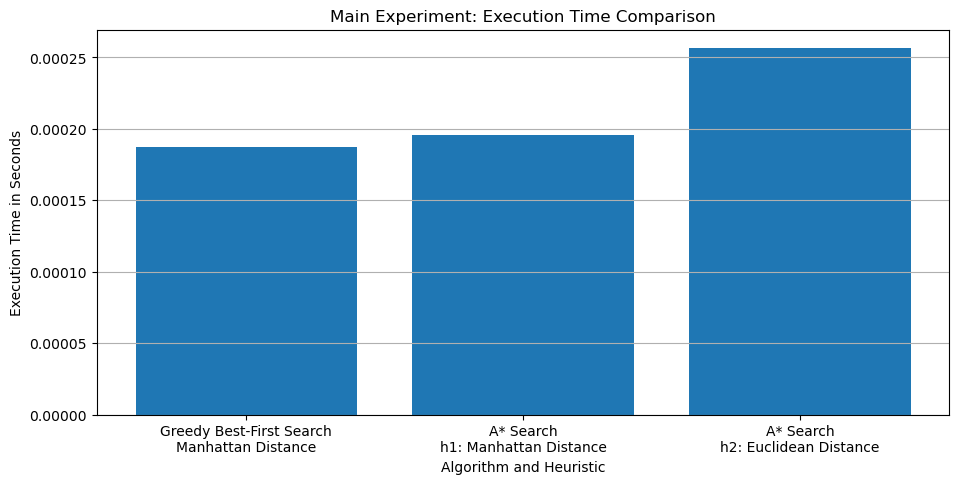

In [13]:
labels = df_results["Algorithm"] + "\n" + df_results["Heuristic"]

plt.figure(figsize=(11, 5))
plt.bar(labels, df_results["Execution Time"])
plt.title("Main Experiment: Execution Time Comparison")
plt.xlabel("Algorithm and Heuristic")
plt.ylabel("Execution Time in Seconds")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## 12. Specific Test Case: Greedy Failure vs A* Success

According to the project requirements, a specific test case must be shown where Greedy Best-First Search fails to find the optimal path, while A* Search succeeds.

The following grid is intentionally designed to demonstrate this case.

The direct path from the start to the goal looks closer according to the heuristic, but it passes through high-cost mountain cells. Greedy Best-First Search is expected to choose this direct-looking path because it only depends on \(h(n)\).

A* Search, however, considers both \(g(n)\) and \(h(n)\), so it avoids the expensive mountain path and chooses a longer but cheaper route.

## Failure Grid

In [14]:
failure_grid = [
    ['S', 'M', 'M', 'M', 'M', 'M', 'M', 'M', 'G'],
    ['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R'],
    ['R', 'X', 'X', 'X', 'X', 'X', 'X', 'X', 'R'],
    ['R', 'R', 'R', 'R', 'R', 'R', 'R', 'R', 'R']
]

failure_start = find_position(failure_grid, 'S')
failure_goal = find_position(failure_grid, 'G')

print("Failure Test Case Grid:")
for row in failure_grid:
    print(" ".join(row))

print("\nStart Position:", failure_start)
print("Goal Position:", failure_goal)

Failure Test Case Grid:
S M M M M M M M G
R R R R R R R R R
R X X X X X X X R
R R R R R R R R R

Start Position: (0, 0)
Goal Position: (0, 8)


## Run Greedy on Failure Test Case

In [15]:
start_time = time.time()

failure_greedy_path, failure_greedy_cost, failure_greedy_nodes = greedy_best_first_search(
    failure_grid,
    failure_start,
    failure_goal,
    manhattan_distance
)

failure_greedy_time = time.time() - start_time

print("Greedy Best-First Search on Failure Test Case")
print("-" * 50)
print("Heuristic Used: Manhattan Distance")
print("Path:", failure_greedy_path)
print("Path Cost:", failure_greedy_cost)
print("Nodes Explored:", failure_greedy_nodes)
print("Execution Time:", failure_greedy_time)

print("\nPath on Grid:")
display_path(failure_grid, failure_greedy_path)

Greedy Best-First Search on Failure Test Case
--------------------------------------------------
Heuristic Used: Manhattan Distance
Path: [(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8)]
Path Cost: 36
Nodes Explored: 9
Execution Time: 0.000110626220703125

Path on Grid:
S * * * * * * * G
R R R R R R R R R
R X X X X X X X R
R R R R R R R R R


## Run A* on Failure Test Case

In [16]:
start_time = time.time()

failure_astar_path, failure_astar_cost, failure_astar_nodes = a_star_search(
    failure_grid,
    failure_start,
    failure_goal,
    manhattan_distance
)

failure_astar_time = time.time() - start_time

print("A* Search on Failure Test Case")
print("-" * 50)
print("Heuristic Used: Manhattan Distance")
print("Path:", failure_astar_path)
print("Path Cost:", failure_astar_cost)
print("Nodes Explored:", failure_astar_nodes)
print("Execution Time:", failure_astar_time)

print("\nPath on Grid:")
display_path(failure_grid, failure_astar_path)

A* Search on Failure Test Case
--------------------------------------------------
Heuristic Used: Manhattan Distance
Path: [(0, 0), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (0, 8)]
Path Cost: 10
Nodes Explored: 11
Execution Time: 9.799003601074219e-05

Path on Grid:
S M M M M M M M G
* * * * * * * * *
R X X X X X X X R
R R R R R R R R R


## Failure Case Comparison Table

In [17]:
failure_results = [
    {
        "Algorithm": "Greedy Best-First Search",
        "Heuristic": "Manhattan Distance",
        "Path Cost": failure_greedy_cost,
        "Nodes Explored": failure_greedy_nodes,
        "Execution Time": failure_greedy_time,
        "Path": failure_greedy_path
    },
    {
        "Algorithm": "A* Search",
        "Heuristic": "Manhattan Distance",
        "Path Cost": failure_astar_cost,
        "Nodes Explored": failure_astar_nodes,
        "Execution Time": failure_astar_time,
        "Path": failure_astar_path
    }
]

df_failure_results = pd.DataFrame(failure_results)
df_failure_results[["Algorithm", "Heuristic", "Path Cost", "Nodes Explored", "Execution Time"]]

,Algorithm,Heuristic,Path Cost,Nodes Explored,Execution Time
0,Greedy Best-First Search,Manhattan Distance,36,9,0.000111
1,A* Search,Manhattan Distance,10,11,0.000098


## Failure Test Case Results Visualization

The following charts visualize the failure test case results.  
This test case is designed to show that Greedy Best-First Search can fail to find the optimal path, while A* Search can find a lower-cost path.

## Failure Path Cost Comparison

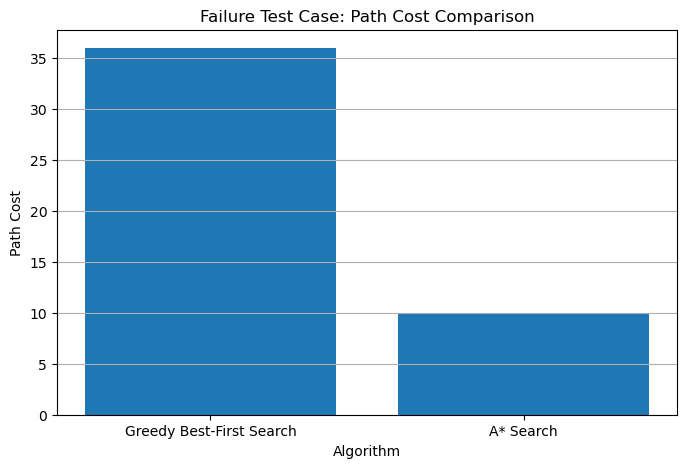

In [18]:
failure_labels = df_failure_results["Algorithm"]

plt.figure(figsize=(8, 5))
plt.bar(failure_labels, df_failure_results["Path Cost"])
plt.title("Failure Test Case: Path Cost Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Path Cost")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Failure Nodes Explored Comparison

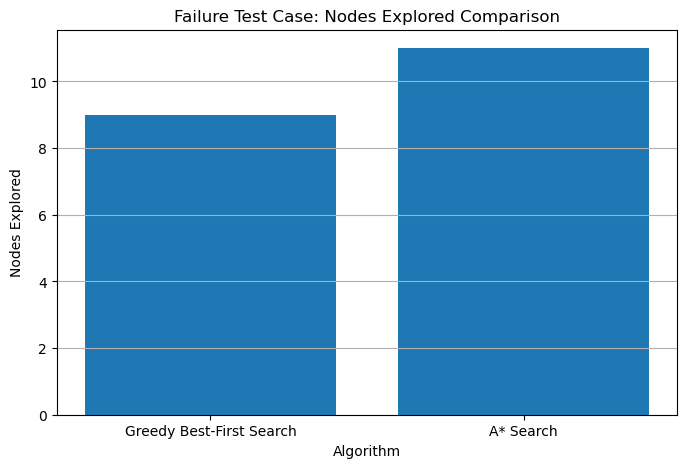

In [19]:
failure_labels = df_failure_results["Algorithm"]

plt.figure(figsize=(8, 5))
plt.bar(failure_labels, df_failure_results["Nodes Explored"])
plt.title("Failure Test Case: Nodes Explored Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Nodes Explored")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Failure Execution Time Comparison

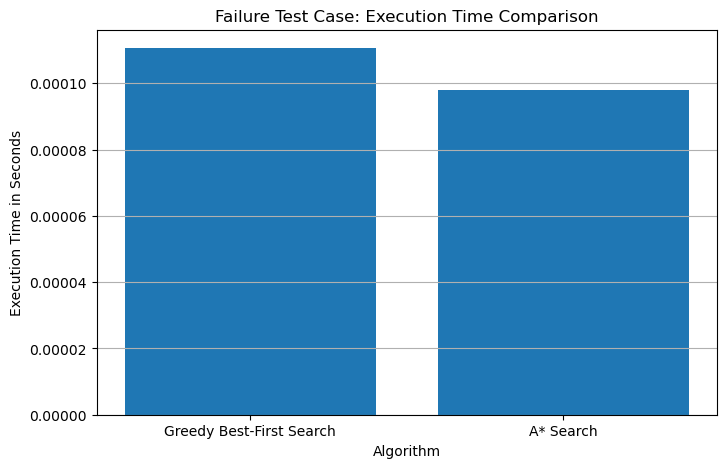

In [20]:
failure_labels = df_failure_results["Algorithm"]

plt.figure(figsize=(8, 5))
plt.bar(failure_labels, df_failure_results["Execution Time"])
plt.title("Failure Test Case: Execution Time Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Execution Time in Seconds")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

## Final Summary Visualization

The following charts summarize the most important results of the project:

1. The main experiment comparison between Greedy and A* with two heuristics.
2. The failure test case comparison showing that Greedy can fail while A* succeeds.

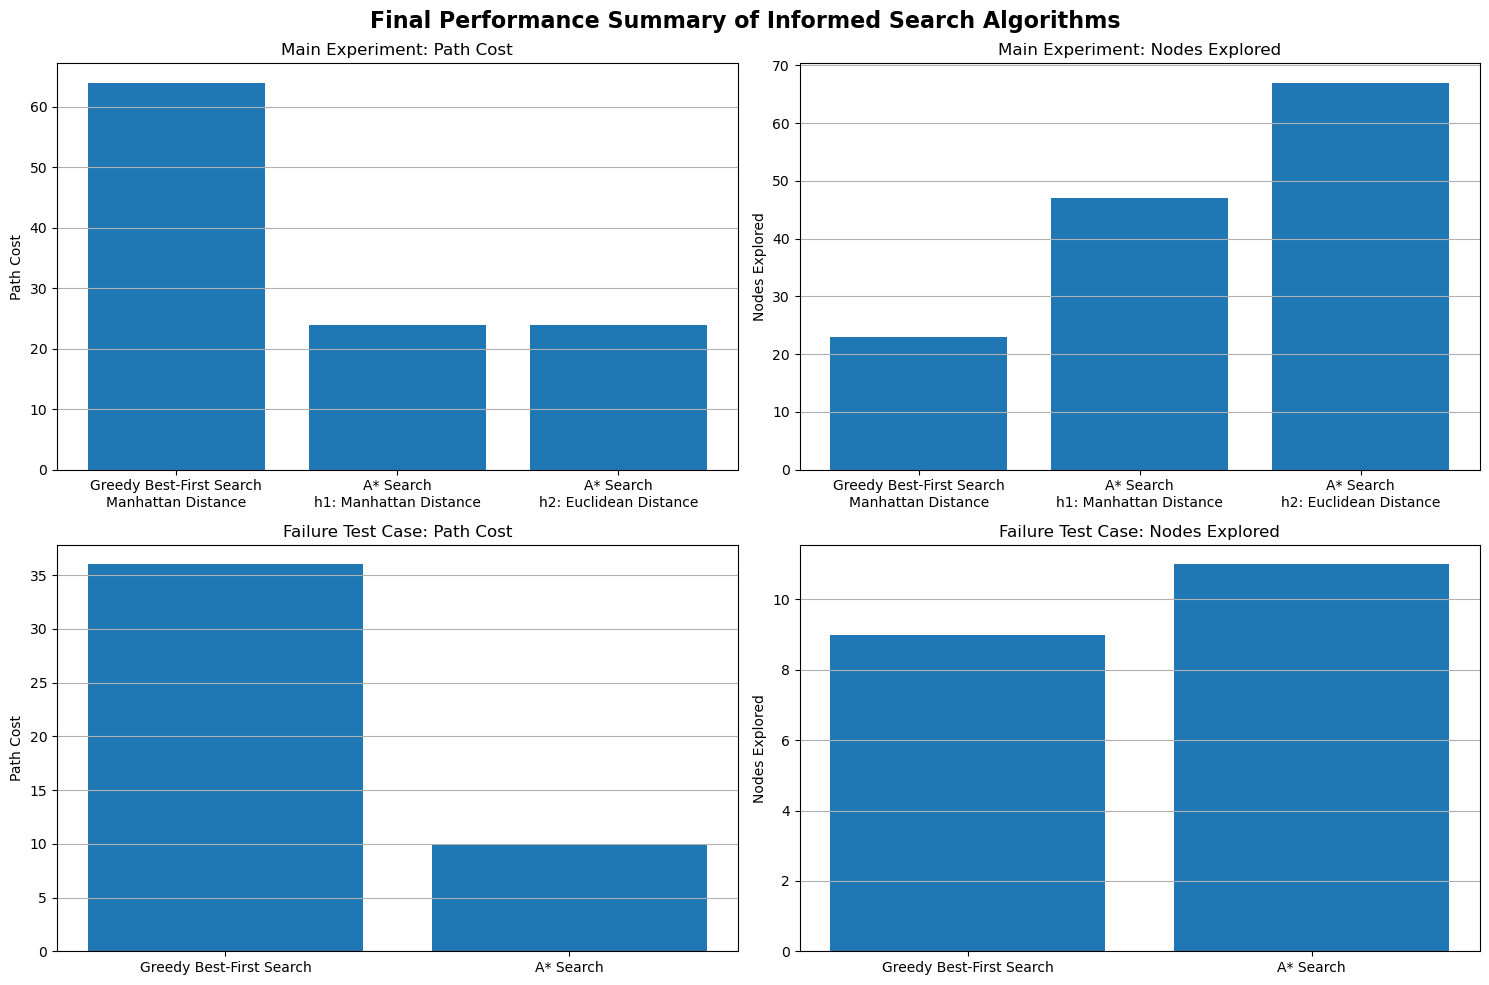

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

main_labels = df_results["Algorithm"] + "\n" + df_results["Heuristic"]
failure_labels = df_failure_results["Algorithm"]

axes[0, 0].bar(main_labels, df_results["Path Cost"])
axes[0, 0].set_title("Main Experiment: Path Cost")
axes[0, 0].set_ylabel("Path Cost")
axes[0, 0].tick_params(axis="x", rotation=0)
axes[0, 0].grid(axis="y")

axes[0, 1].bar(main_labels, df_results["Nodes Explored"])
axes[0, 1].set_title("Main Experiment: Nodes Explored")
axes[0, 1].set_ylabel("Nodes Explored")
axes[0, 1].tick_params(axis="x", rotation=0)
axes[0, 1].grid(axis="y")

axes[1, 0].bar(failure_labels, df_failure_results["Path Cost"])
axes[1, 0].set_title("Failure Test Case: Path Cost")
axes[1, 0].set_ylabel("Path Cost")
axes[1, 0].tick_params(axis="x", rotation=0)
axes[1, 0].grid(axis="y")

axes[1, 1].bar(failure_labels, df_failure_results["Nodes Explored"])
axes[1, 1].set_title("Failure Test Case: Nodes Explored")
axes[1, 1].set_ylabel("Nodes Explored")
axes[1, 1].tick_params(axis="x", rotation=0)
axes[1, 1].grid(axis="y")

fig.suptitle("Final Performance Summary of Informed Search Algorithms", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

## Automatic Conclusion

In [22]:
if failure_greedy_cost > failure_astar_cost:
    print("Conclusion:")
    print("Greedy Best-First Search failed to find the optimal path.")
    print("It selected a path with higher total cost because it only used h(n).")
    print("A* Search succeeded in finding a lower-cost path because it used g(n) + h(n).")
else:
    print("In this test case, Greedy did not fail. The grid should be adjusted.")

Conclusion:
Greedy Best-First Search failed to find the optimal path.
It selected a path with higher total cost because it only used h(n).
A* Search succeeded in finding a lower-cost path because it used g(n) + h(n).


## Explanation Based on \(g(n)\) and \(h(n)\)

The failure test case shows why Greedy Best-First Search failed while A* Search succeeded.

Greedy Best-First Search evaluates nodes using only the heuristic value:

\[
f(n) = h(n)
\]

This means that Greedy only considers how close a node appears to be to the goal. It ignores the actual cost already paid from the start node, which is represented by \(g(n)\).

In the failure test case, the direct path toward the safe zone had a low heuristic value because it was visually closer to the goal. However, this path passed through several mountain cells with high movement cost. Since Greedy ignored \(g(n)\), it selected this expensive path and failed to find the optimal solution.

A* Search evaluates nodes using:

\[
f(n) = g(n) + h(n)
\]

This means that A* considers both:

- \(g(n)\): the actual accumulated movement cost from the start node to the current node
- \(h(n)\): the estimated remaining cost from the current node to the goal

Therefore, A* avoided the expensive direct path because its \(g(n)\) value became high when passing through mountain cells. Instead, it selected a longer-looking route with a lower total cost.

This explains why Greedy Best-First Search failed in this test case, while A* Search succeeded in finding the optimal path.

## Performance Analysis: Greedy Best-First Search vs A*

The failure test case clearly shows the difference between Greedy Best-First Search and A* Search.

Greedy Best-First Search selected the path that looked closer to the goal because it only depends on the heuristic value:

\[
f(n) = h(n)
\]

In the failure grid, the direct path toward the safe zone passed through several mountain cells. Although this path looked closer to the goal, it had a high total movement cost.

A* Search avoided this problem because it uses:

\[
f(n) = g(n) + h(n)
\]

This means that A* considers both the accumulated movement cost and the estimated distance to the goal.

As a result, A* selected a longer-looking path, but with a much lower total cost. This proves that Greedy Best-First Search is not guaranteed to find the optimal path, while A* can find the optimal path when using an admissible heuristic.

## Performance Analysis: A* with h1 vs A* with h2

A* Search was tested using two different admissible heuristic functions:

- \(h_1\): Manhattan Distance
- \(h_2\): Euclidean Distance

Both heuristics are admissible because they never overestimate the true cost from the current node to the goal. Therefore, A* is expected to find an optimal path using either heuristic.

In this project, both A* versions reached the goal successfully. The path cost may be the same because both heuristics are admissible and can lead A* to the optimal solution. However, the difference appears in search efficiency, especially in the number of explored nodes.

Manhattan Distance is more suitable for this problem because the player can only move in four directions: up, down, left, and right. It gives a more accurate estimate for grid-based movement.

Euclidean Distance calculates the straight-line distance to the goal. Since diagonal movement is not allowed, it is usually less informed than Manhattan Distance in this environment.

Therefore, A* with Manhattan Distance is expected to explore fewer nodes than A* with Euclidean Distance, while both can still preserve optimality.

## Summary of Experimental Results

The experiments in this notebook were divided into two parts.

### Main Grid Experiment

The main grid was used to compare:

- Greedy Best-First Search
- A* Search using \(h_1\): Manhattan Distance
- A* Search using \(h_2\): Euclidean Distance

This experiment shows the general performance of the algorithms in a PUBG-inspired weighted grid environment.

### Failure Test Case

The failure test case was designed specifically to satisfy the project requirement of showing a case where Greedy Best-First Search fails to find the optimal path while A* Search succeeds.

In this case, Greedy selected a path that looked closer to the goal but had a higher movement cost. A* selected a lower-cost path because it considered both \(g(n)\) and \(h(n)\).

## Important Theoretical Notes

### Why can Greedy Best-First Search fail?

Greedy Best-First Search can fail because it only uses:

\[
f(n) = h(n)
\]

It ignores the actual accumulated cost \(g(n)\). Therefore, it may choose a path that appears close to the goal but passes through expensive terrain.

### Why can A* find the optimal path?

A* uses:

\[
f(n) = g(n) + h(n)
\]

When the heuristic is admissible, A* can find the optimal path because it considers both the real cost from the start and the estimated cost to the goal.

### Why is Manhattan Distance admissible?

Manhattan Distance does not overestimate the true cost because the player can only move horizontally or vertically, and the minimum valid movement cost is 1.

### Why is Euclidean Distance admissible?

Euclidean Distance is the straight-line distance to the goal. Since the actual grid path cannot be shorter than the straight-line distance, it does not overestimate the true cost.

## Discussion

This project demonstrates how informed search algorithms behave in a weighted grid environment.

Greedy Best-First Search was able to reach the goal, but it was not guaranteed to find the optimal path because it only depends on the heuristic value \(h(n)\). In the failure test case, Greedy selected the direct-looking path toward the safe zone, but this path passed through expensive mountain cells.

A* Search performed better because it uses:

\[
f(n) = g(n) + h(n)
\]

This means that A* considers both the accumulated movement cost and the estimated distance to the goal. As a result, A* avoided the expensive direct path and selected a lower-cost route.

The comparison between A* using Manhattan Distance and A* using Euclidean Distance showed that both heuristics preserved optimality. However, Manhattan Distance explored fewer nodes because it is more suitable for four-direction grid movement.

Overall, the results show that A* is more reliable than Greedy Best-First Search in weighted pathfinding problems, and that the choice of heuristic affects the efficiency of the search.

## Conclusion

In this project, a PUBG-inspired safe zone pathfinding problem was solved using informed search algorithms.

The environment was represented as a weighted 2D grid. Each cell represented a terrain type with a different movement cost. The player had to move from the starting position to the safe zone while minimizing the total path cost.

Two informed search algorithms were implemented:

- Greedy Best-First Search
- A* Search

Two admissible heuristic functions were also implemented:

- Manhattan Distance
- Euclidean Distance

The results showed that Greedy Best-First Search is not guaranteed to find the optimal path because it only considers the heuristic value \(h(n)\). In the failure test case, Greedy selected a higher-cost path because it ignored the accumulated movement cost.

A* Search performed better because it considered both \(g(n)\) and \(h(n)\). This allowed it to find a lower-cost path in the weighted grid environment.

The comparison between A* using Manhattan Distance and A* using Euclidean Distance showed that both heuristics can preserve optimality, but Manhattan Distance is generally more efficient for four-direction grid movement.

![PUBG Player Reached Safe Zone](pubg_player.jpg)

*Figure: The player successfully reaches the safe zone after applying informed search algorithms.*